## 5 Idiom Classification

This notebook uses the decoder embeddings of the fine tuned whisper model to train an audio idiom classifier.

In [5]:
# Cell 1: Imports & Setup
import sys
import os
from pathlib import Path
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from transformers import WhisperProcessor, WhisperForConditionalGeneration

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import load_all_data, extract_decoder_embeddings, train_classifier
from whisper_asr.utils import get_best_gpu

os.environ["TOKENIZERS_PARALLELISM"] = "false"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Selected GPU 7 with 24121 MiB free memory
Using device: cuda:7


In [6]:
# Cell 2: Load model & processor
MODEL_PATH = "../models/whisper-medium-rm-all-it"
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)
print("Model loaded.")

Loading weights: 100%|██████████| 947/947 [00:00<00:00, 5197.12it/s]


Model loaded.


In [7]:
# Cell 3: Load data (train and test splits)
train_df = load_all_data("train")
test_df = load_all_data("test")

In [4]:
# Cell 4: Extract embeddings for train and test sets
print("Extracting train embeddings...")
train_embeddings = extract_decoder_embeddings(
    model, processor,
    train_df["audio_path"].tolist(),
    train_df["sentence"].tolist(),
    device=DEVICE, batch_size=8
)
print("Extracting test embeddings...")
test_embeddings = extract_decoder_embeddings(
    model, processor,
    test_df["audio_path"].tolist(),
    test_df["sentence"].tolist(),
    device=DEVICE, batch_size=8
)

Extracting train embeddings...


Extracting decoder embeddings:   0%|          | 0/3696 [00:00<?, ?it/s]

Extracting decoder embeddings:   1%|▏         | 55/3696 [00:54<1:00:34,  1.00it/s]


KeyboardInterrupt: 

In [ ]:
# Cell 5: Train classifier and evaluate
train_labels = train_df["idiom"].tolist()
test_labels = test_df["idiom"].tolist()

classifier, predictions = train_classifier(
    train_embeddings, train_labels,
    test_embeddings, test_labels
)

# Optionally save the classifier
joblib.dump(classifier, "../models/idiom_classifier.pkl")

Extracting decoder embeddings: 100%|██████████| 79/79 [01:34<00:00,  1.20s/it]


Absolute counts:
Predicted idiom  Puter  RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                          
Puter              112   0         0          0          0         2
RG                   0  80         0          1          0         0
Surmiran             0   0       151          0          0         0
Sursilvan            0   0         0         94          0         0
Sutsilvan            0   0         0          0         94         0
Vallader             1   0         1          0          0        95

Normalized (by true idiom):
Predicted idiom  Puter     RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                             
Puter            0.982  0.000      0.00      0.000        0.0     0.018
RG               0.000  0.988      0.00      0.012        0.0     0.000
Surmiran         0.000  0.000      1.00      0.000        0.0     0.000
Sursilvan        0.000  0.000      0.00   

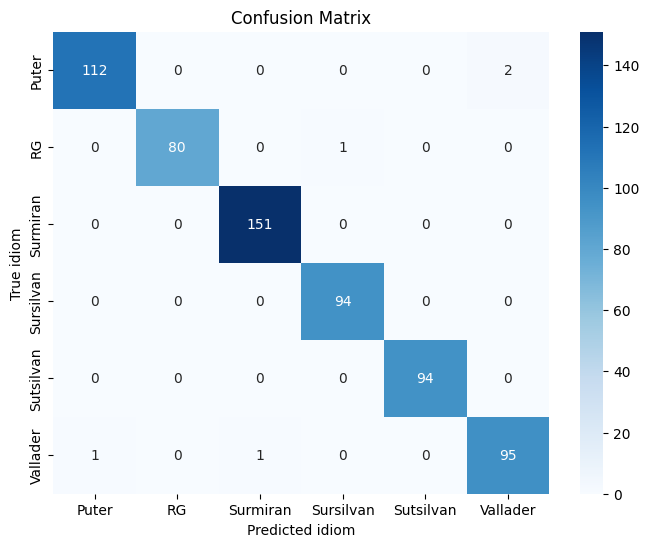

In [11]:
classifier = joblib.load("../models/idiom_classifier.pkl")
test_embeddings = extract_decoder_embeddings(
    model, processor,
    test_df["audio_path"].tolist(),
    test_df["sentence"].tolist(),
    device=DEVICE, batch_size=8
)
predictions = classifier.predict(test_embeddings)
cm = confusion_matrix(test_labels, predictions, labels=classifier.classes_)

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=classifier.classes_, columns=classifier.classes_)
cm_df.index.name = "True idiom"
cm_df.columns.name = "Predicted idiom"

print("Absolute counts:")
print(cm_df)

# Normalized by row (true idiom) → percentages
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3)
print("\nNormalized (by true idiom):")
print(cm_norm)

# Optional heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()